# FGSM Adversarial Attacks

## Fast Gradient Sign Method - Implementazione e Valutazione

Questo notebook implementa attacchi FGSM da zero e valuta l'accuratezza del modello ResNet18 addestrato

## 1. Setup e Import

In [8]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path('..')
BATCH_SIZE = 32
IMG_SIZE = 224
N_CLASSES = 5


model = models.resnet18(pretrained=True)
model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
model = model.to(device)

model_path = ROOT / "models" / "best_resnet18.pt"
model.load_state_dict(torch.load(model_path))
model.eval()


NORMALIZE = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset_path = ROOT / "data" / "fruits-classification-stratified"

train_dataset = ImageFolder(root=dataset_path / 'train', transform=TRANSFORMS)
val_dataset = ImageFolder(root=dataset_path / 'valid', transform=TRANSFORMS)
test_dataset = ImageFolder(root=dataset_path / 'test', transform=TRANSFORMS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

class_names = test_dataset.classes

results_path = ROOT / "results"
results_path.mkdir(exist_ok=True)

print(f"\nSetup e import completati")



Setup e import completati


/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 2. Implementazione FGSM (da zero)

FGSM (Fast Gradient Sign Method) è il metodo più semplice per creare esempi adversarial:

1. Calcola il gradiente della loss rispetto all'immagine
2. Prende il segno del gradiente (direzione di massimo aumento dell'errore)
3. Moltiplica per epsilon e aggiunge all'immagine

In [9]:
def fgsm_attack(model, images, labels, epsilon, loss_fn):
    """
    Esegue un attacco FGSM su un batch di immagini
    
    Args:
        model: il modello target da ingannare
        images: batch di immagini 
        labels: label vere per il batch 
        epsilon: grandezza della perturbazione (0.01 - 0.5)
        loss_fn: funzione di loss (CrossEntropyLoss)
    
    Returns:
        adv_images: immagini perturbate 
        perturbation: il rumore aggiunto 
    """
    
    # abilita il calcolo dei gradienti rispetto alle immagini
    images.requires_grad = True
    
    outputs = model(NORMALIZE(images))
    loss = loss_fn(outputs, labels)
    
    # pulisce i gradienti precedenti (utile se si chiama la funzione piu volte)
    model.zero_grad()
    
    loss.backward()
    
    # estrae il segno dei gradienti (solo direzione, non ampiezza)
    gradient_sign = images.grad.sign()
    
    perturbation = epsilon * gradient_sign
    adv_images = images + perturbation
    
    # Clip i valori nel range [0, 1] (valori pixel validi)
    adv_images = torch.clamp(adv_images, 0, 1)
    
    # per adesso non mi servono i gradienti, quindi scollego le immagini perturbate (libero memoria)
    adv_images = adv_images.detach()
    images.requires_grad = False
    
    return adv_images, perturbation.detach()


print("Funzione FGSM implementata")

Funzione FGSM implementata


## 3. Test FGSM con Epsilon diversi

Testare l'attacco FGSM su diversi valori di epsilon per capire quando il modello inizia a sbagliare.

Metriche:
- **Accuracy**: % di immagini classificate correttamente dal modello (senza attacco)
- **Attack Success Rate (ASR)**: % di immagini dove l'attacco ha ingannato il modello
- **Time**: tempo totale per applicare l'attacco al test set

In [10]:
epsilon_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5] 
epsilon_to_visualize = [0.01, 0.3, 0.5]

loss_fn = nn.CrossEntropyLoss()
fgsm_results = {}

examples_store = {eps: {'success': [], 'failure': []} for eps in epsilon_to_visualize}

for epsilon in epsilon_values:
    print(f"\nTest epsilon = {epsilon}")

    correct_original = 0 
    correct_adv = 0  
    attack_success_count = 0
    total_samples = 0

    start_time = time.time()

    model.eval()

    for images, labels in tqdm(test_loader, desc=f"epsilon={epsilon}"):
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs_original = model(NORMALIZE(images))
            preds_original = torch.argmax(outputs_original, dim=1)
            correct_original += (preds_original == labels).sum().item()

        # ATTACCO FGSM
        adv_images, perturbation = fgsm_attack(
            model,
            images.clone().requires_grad_(True),
            labels,
            epsilon,
            loss_fn,
        )

        with torch.no_grad():
            outputs_adv = model(NORMALIZE(adv_images))  
            preds_adv = torch.argmax(outputs_adv, dim=1)
            correct_adv += (preds_adv == labels).sum().item()

        success = (preds_original == labels) & (preds_adv != labels)
        attack_success_count += success.sum().item()

        total_samples += labels.size(0)

        if epsilon in epsilon_to_visualize:
           for i in range(images.size(0)):
            pred_orig = preds_original[i].item()
            pred_adv = preds_adv[i].item()
            true_label = labels[i].item()

            attack_success = pred_orig == true_label and pred_adv != true_label
            attack_failure = pred_orig == true_label and pred_adv == true_label

            example = {
                'image': images[i:i+1].detach().cpu().clone(),
                'adv_image': adv_images[i:i+1].detach().cpu().clone(),
                'perturbation': perturbation[i:i+1].detach().cpu().clone(),
                'pred_original': pred_orig,
                'pred_adv': pred_adv,
                'true_label': true_label,
            }

            if attack_success: examples_store[epsilon]['success'].append(example)

            elif attack_failure: examples_store[epsilon]['failure'].append(example) 

    # metriche    
    accuracy = correct_original / total_samples
    accuracy_adv = correct_adv / total_samples
    accuracy_drop = accuracy - accuracy_adv
    asr = attack_success_count / correct_original  
    elapsed_time = time.time() - start_time

    fgsm_results[epsilon] = {
        'accuracy': accuracy,
        'accuracy_adv': accuracy_adv,
        'accuracy_drop': accuracy_drop,
        'asr': asr,
        'time': elapsed_time,
    }

    print(f"  Accuracy (clean): {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Accuracy (adversarial): {accuracy_adv:.4f} ({accuracy_adv*100:.2f}%)")
    print(f"  Accuracy Drop: {accuracy_drop:.4f} ({accuracy_drop*100:.2f}%)")
    print(f"  Attack Success Rate: {asr:.4f} ({asr*100:.2f}%)")
    print(f"  Tempo: {elapsed_time:.2f}s")

print("\nTest completato per tutti gli epsilon")


Test epsilon = 0.01


epsilon=0.01: 100%|██████████| 32/32 [00:02<00:00, 14.89it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.1443 (14.43%)
  Accuracy Drop: 0.7675 (76.75%)
  Attack Success Rate: 0.8418 (84.18%)
  Tempo: 2.15s

Test epsilon = 0.05


epsilon=0.05: 100%|██████████| 32/32 [00:00<00:00, 35.65it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.1353 (13.53%)
  Accuracy Drop: 0.7766 (77.66%)
  Attack Success Rate: 0.8516 (85.16%)
  Tempo: 0.90s

Test epsilon = 0.1


...

  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.2595 (25.95%)
  Accuracy Drop: 0.6523 (65.23%)
  Attack Success Rate: 0.7242 (72.42%)
  Tempo: 0.89s

Test epsilon = 0.3


epsilon=0.3: 100%|██████████| 32/32 [00:02<00:00, 15.47it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.2595 (25.95%)
  Accuracy Drop: 0.6523 (65.23%)
  Attack Success Rate: 0.7286 (72.86%)
  Tempo: 2.07s

Test epsilon = 0.5


epsilon=0.5: 100%|██████████| 32/32 [00:01<00:00, 19.51it/s]

  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.2244 (22.44%)
  Accuracy Drop: 0.6874 (68.74%)
  Attack Success Rate: 0.7791 (77.91%)
  Tempo: 1.64s

Test completato per tutti gli epsilon


## 4. Plot delle immagini perturbate

Per ogni epsilon verranno mostrate:
- immagini originali
- perturbazioni (rumore aggiunto)
- immagini perturbate (originale + rumore)

Questo aiuta a capire quanto l'attacco sia "visibile" all'occhio umano e come confonde il modello.


Epsilon = 0.01


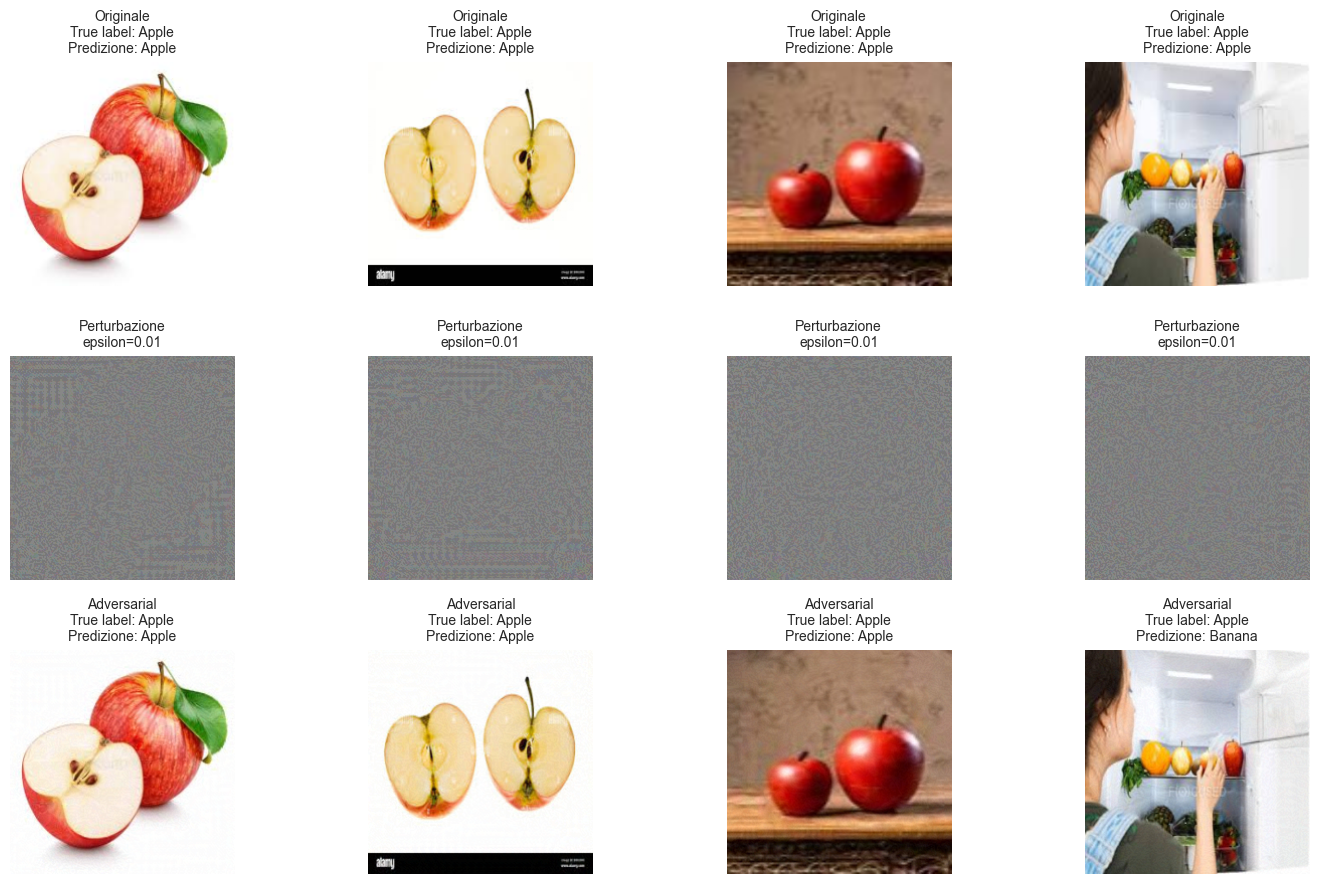


Epsilon = 0.3


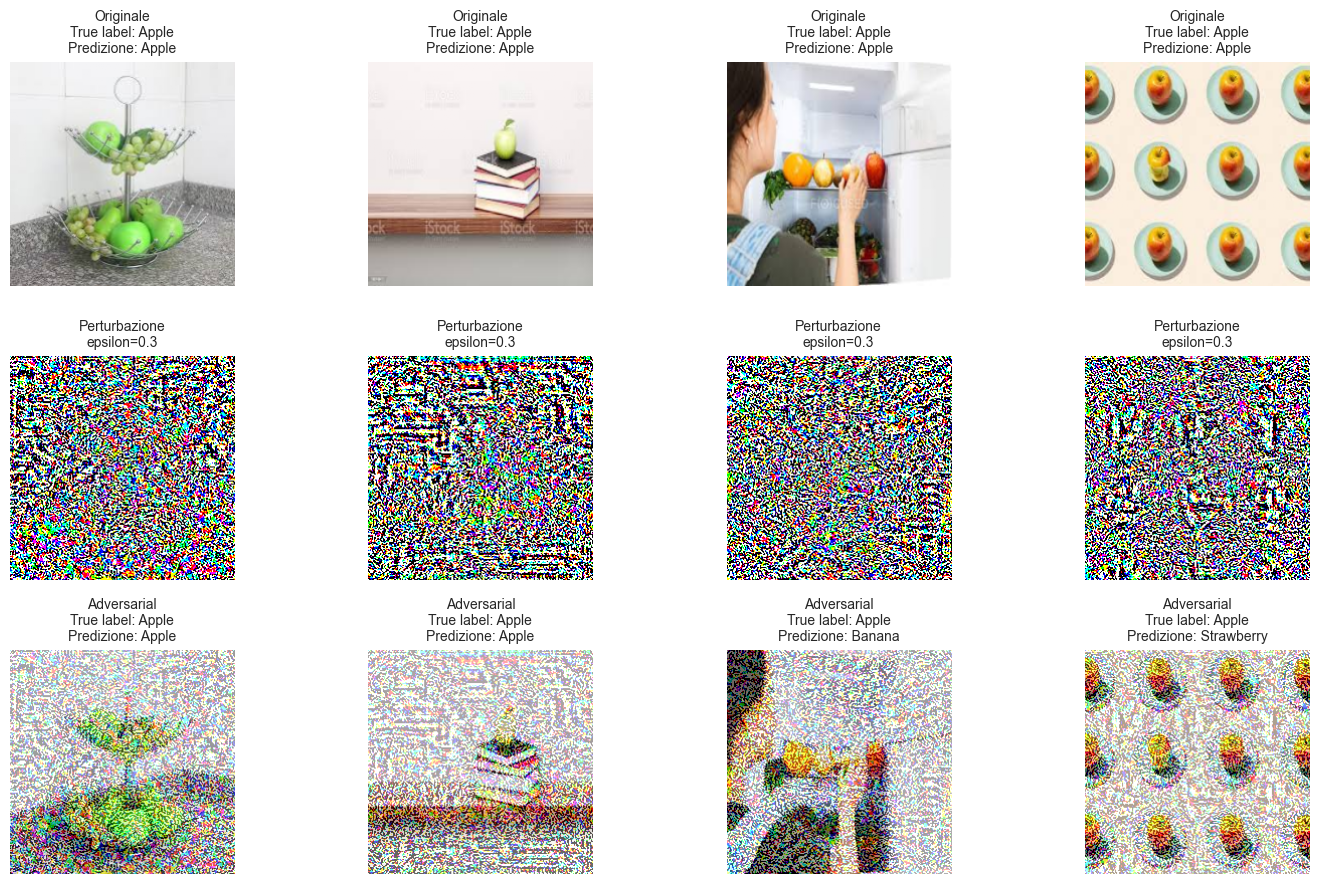


Epsilon = 0.5


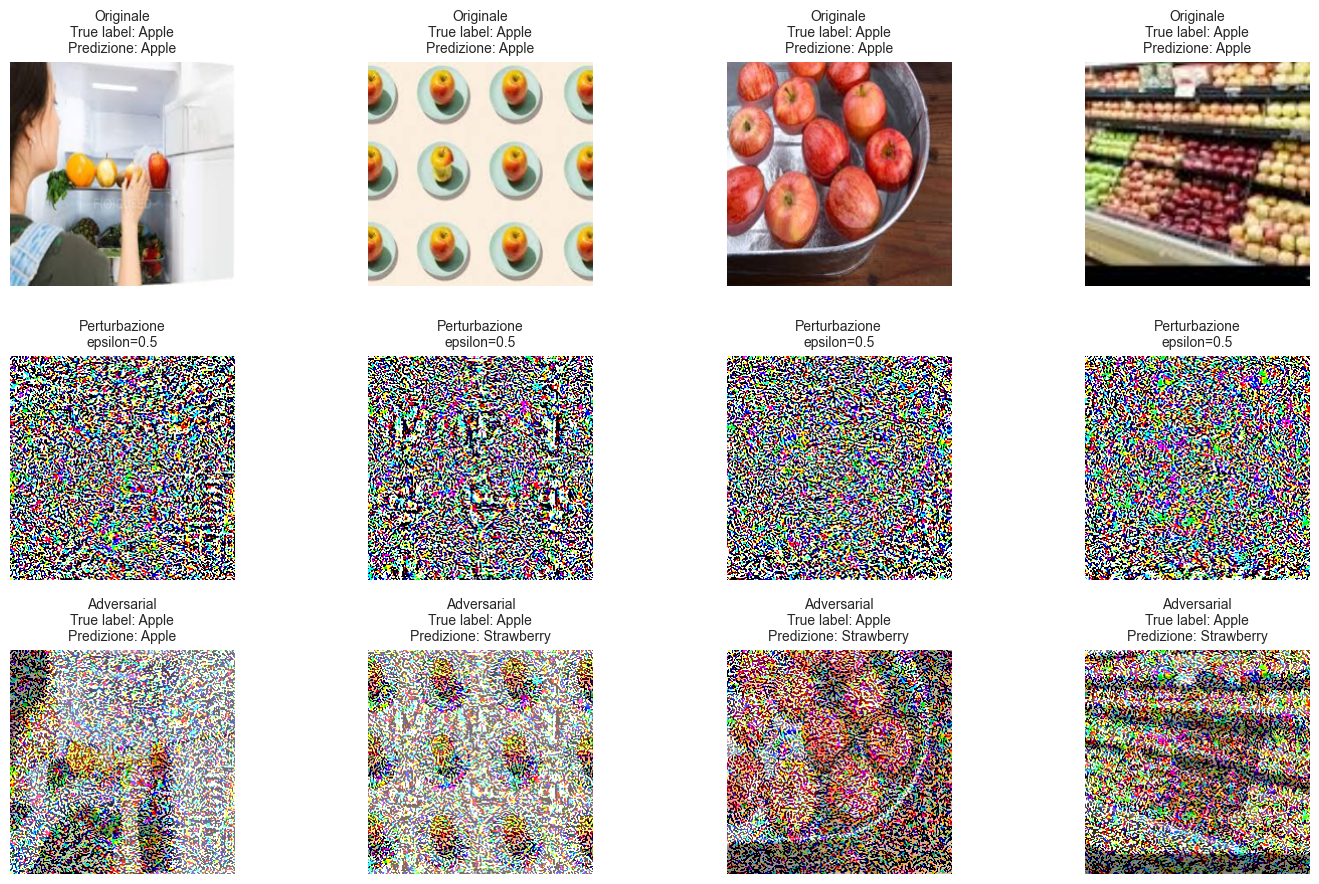

In [11]:
# eps=0.01: 3 classificate bene + 1 classificata male
# eps=0.3: 2 classificate bene + 2 classificate male
# eps=0.5: 1 classificata bene + 3 classificate male
# scelti arbitrariamente

plot_config = {
    0.01: {'correct': 3, 'wrong': 1},
    0.3: {'correct': 2, 'wrong': 2},
    0.5: {'correct': 1, 'wrong': 3},
}

for epsilon in epsilon_to_visualize:
    selected_examples = (
        examples_store[epsilon]['failure'][:plot_config[epsilon]['correct']] +
        examples_store[epsilon]['success'][:plot_config[epsilon]['wrong']]
    )

    fig, axes = plt.subplots(3, 4, figsize=(15, 9))

    for img_idx in range(4):
        example = selected_examples[img_idx]

        img_original = example['image'][0].numpy()
        img_original = np.transpose(img_original, (1, 2, 0))
        img_original = np.clip(img_original, 0, 1)

        perturbation = example['perturbation'][0].numpy()
        perturbation = np.transpose(perturbation, (1, 2, 0))
        perturbation = perturbation * 3 + 0.5 # cosi si vede meglio
        perturbation = np.clip(perturbation, 0, 1)

        img_adv = example['adv_image'][0].numpy()
        img_adv = np.transpose(img_adv, (1, 2, 0))
        img_adv = np.clip(img_adv, 0, 1)

        true_label = example['true_label']
        pred_original = example['pred_original']
        pred_adv = example['pred_adv']

        # immagini originali
        ax = axes[0, img_idx]
        ax.imshow(img_original)
        ax.set_title(f"Originale\nTrue label: {class_names[true_label]}\nPredizione: {class_names[pred_original]}", fontsize=10)
        ax.axis('off')

        # perturbazioni
        ax = axes[1, img_idx]
        ax.imshow(perturbation)
        ax.set_title(f"Perturbazione\nepsilon={epsilon}", fontsize=10)
        ax.axis('off')

        # immagini adversarial
        ax = axes[2, img_idx]
        ax.imshow(img_adv)
        ax.set_title(f"Adversarial\nTrue label: {class_names[true_label]}\nPredizione: {class_names[pred_adv]}", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(results_path / f"fgsm_attack_{epsilon}.png", dpi=120, bbox_inches='tight')
    print(f"\nEpsilon = {epsilon}")
    plt.show()

## 5. Plot delle Metriche 

Generazioe di grafici riguardanti le metriche:
- Accuracy su immagini originali vs immagini perturbate
- Calo di accuracy (accuracy drop)
- Attack Success Rate (ASR)
- Tempo per applicare l'attacco al test set

/tmp/ipykernel_2238620/1275653133.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
/tmp/ipykernel_2238620/1275653133.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
/tmp/ipykernel_2238620/1275653133.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)


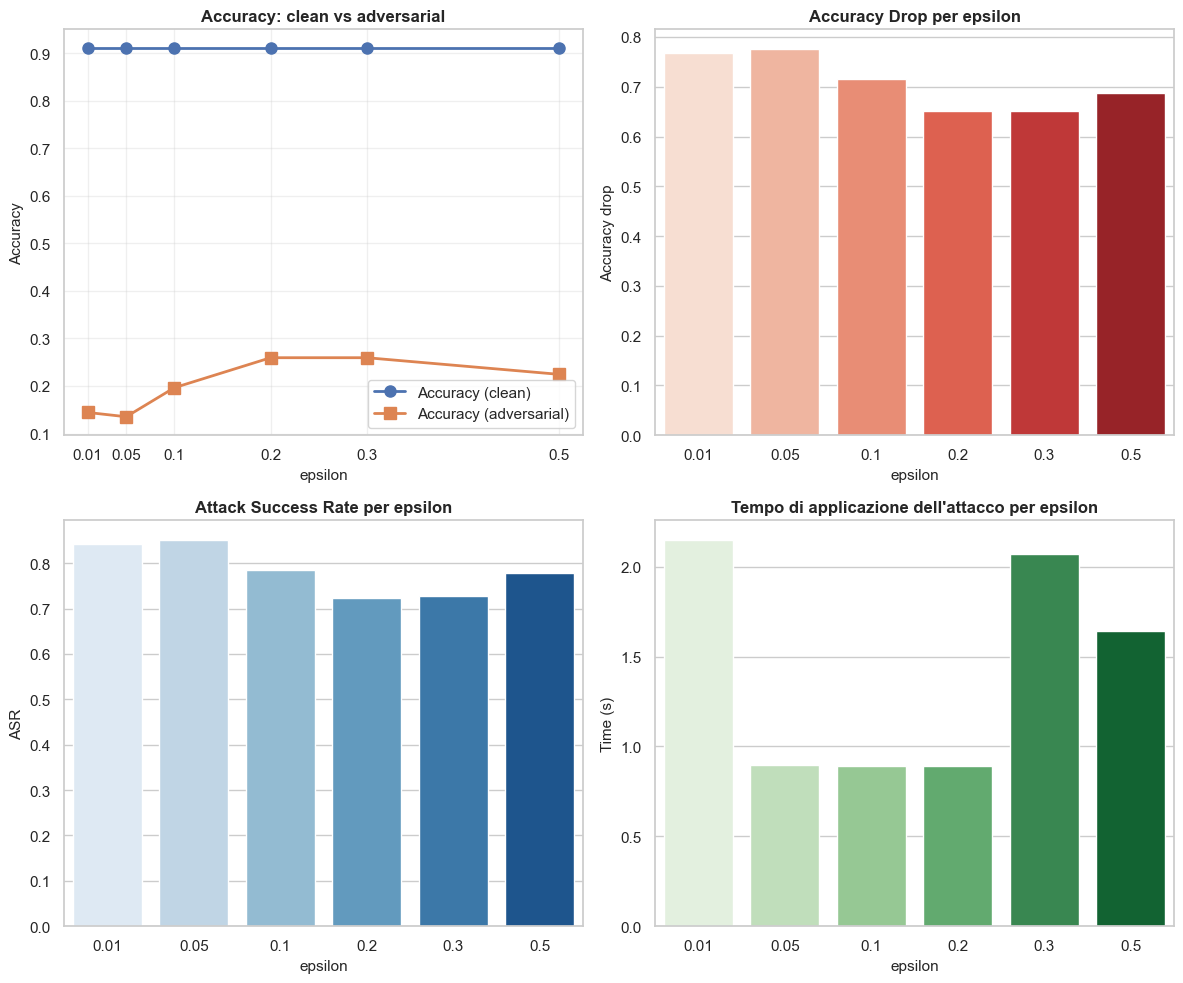

In [12]:
eps = epsilon_values
acc = [fgsm_results[e]['accuracy'] for e in eps]
acc_adv = [fgsm_results[e]['accuracy_adv'] for e in eps]
acc_drop = [fgsm_results[e]['accuracy_drop'] for e in eps]
asr = [fgsm_results[e]['asr'] for e in eps]
times = [fgsm_results[e]['time'] for e in eps]

eps_labels = [str(e) for e in eps]

sns.set(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# accuracy: clean vs adversarial
ax = axes[0, 0]
ax.plot(eps, acc, marker='o', label='Accuracy (clean)', linewidth=2, markersize=8)
ax.plot(eps, acc_adv, marker='s', label='Accuracy (adversarial)', linewidth=2, markersize=8)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_xticks(eps)
ax.set_xticklabels(eps_labels)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy: clean vs adversarial', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# accuracy drop
ax = axes[0, 1]
sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('Accuracy drop', fontsize=11)
ax.set_title('Accuracy Drop per epsilon', fontsize=12, fontweight='bold')

# Attack Success Rate (ASR)
ax = axes[1, 0]
sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('ASR', fontsize=11)
ax.set_title('Attack Success Rate per epsilon', fontsize=12, fontweight='bold')

# tempo
ax = axes[1, 1]
sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('Time (s)', fontsize=11)
ax.set_title("Tempo di applicazione dell'attacco per epsilon", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(results_path / 'FGSM_metrics_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# tabella riassuntiva
summary_df = pd.DataFrame({
    'epsilon': eps,
    'accuracy': acc,
    'accuracy_adv': acc_adv,
    'accuracy_drop': acc_drop,
    'asr': asr,
    'time_s': times,
})
summary_df.to_csv(results_path / 'FGSM_metrics_summary.csv', index=False)

## 6. Adversarial Training

Addestramwnto di un nuovo modello con dati misti: 50% immagini originali + 50% immagini perturbate (FGSM con epsilon=0.1)

In [13]:
epsilon_adv_training = 0.1

fgsm_model = models.resnet18(pretrained=True)
fgsm_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
fgsm_model = fgsm_model.to(device)

model_path = ROOT / "models" / "best_resnet18.pt"
fgsm_model.load_state_dict(torch.load(model_path))

adv_loss_fn = nn.CrossEntropyLoss()
adv_optimizer = torch.optim.Adam(fgsm_model.parameters(), lr=0.0001)

num_epochs = 50
patience = 20
best_val_loss = float('inf')
patience_counter = 0

model_save_path = ROOT / "models" / "best_fgsm_eps_001.pt"
model_save_path.parent.mkdir(parents=True, exist_ok=True)

adv_train_history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(num_epochs):
    fgsm_model.train()

    epoch_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device)

        batch_size_half = images.size(0) // 2

        clean_images = images[:batch_size_half]

        adv_images, perturbation = fgsm_attack(
            fgsm_model,
            images[batch_size_half:],
            labels[batch_size_half:],
            epsilon_adv_training,
            adv_loss_fn
        )

        mixed_images = torch.cat([clean_images, adv_images], dim=0)
        mixed_labels = labels

        adv_optimizer.zero_grad()
        outputs = fgsm_model(NORMALIZE(mixed_images))
        loss = adv_loss_fn(outputs, mixed_labels)
        loss.backward()
        adv_optimizer.step()

        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = epoch_loss / len(train_loader)
    train_acc = correct_train / total_train

    fgsm_model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = fgsm_model(NORMALIZE(images))
            loss = adv_loss_fn(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val

    adv_train_history['train_loss'].append(train_loss)
    adv_train_history['train_acc'].append(train_acc)
    adv_train_history['val_loss'].append(val_loss)
    adv_train_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(fgsm_model.state_dict(), model_save_path)
        print("Nuovo migliore modello salvato")
    else:
        patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

fgsm_model.load_state_dict(torch.load(model_save_path))

print("Adversarial training completato")
print(f"Miglior validation loss: {best_val_loss:.4f}")

/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/50: 100%|██████████| 250/250 [00:04<00:00, 53.17it/s]


Epoch 1: Train Loss=0.6892, Train Acc=0.7263, Val Loss=0.2643, Val Acc=0.9108
Nuovo migliore modello salvato


Epoch 2/50: 100%|██████████| 250/250 [00:04<00:00, 53.36it/s]


Epoch 2: Train Loss=0.5562, Train Acc=0.7761, Val Loss=0.2787, Val Acc=0.8988


Epoch 3/50: 100%|██████████| 250/250 [00:04<00:00, 52.70it/s]


...

Epoch 19: Train Loss=0.2094, Train Acc=0.9174, Val Loss=0.4849, Val Acc=0.8667


Epoch 20/50: 100%|██████████| 250/250 [00:04<00:00, 53.04it/s]


Epoch 20: Train Loss=0.1966, Train Acc=0.9222, Val Loss=0.4637, Val Acc=0.8828


Epoch 21/50: 100%|██████████| 250/250 [00:04<00:00, 52.45it/s]


Epoch 21: Train Loss=0.1756, Train Acc=0.9293, Val Loss=0.4456, Val Acc=0.8788
Early stopping at epoch 21
Adversarial training completato
Miglior validation loss: 0.2643


## 7. Confronto: Modello Originale vs Modello FGSM

Confronto del modello originale con il modello addestrato avversarialmente.

Metriche:
- accuracy clean
- accuracy adversarial
- accuracy drop
- ASR 

Confronto FGSM epsilon=0.1:   0%|          | 0/32 [00:00<?, ?it/s]

Confronto FGSM epsilon=0.1: 100%|██████████| 32/32 [00:01<00:00, 22.95it/s]


                    model  epsilon_attack  accuracy_clean  accuracy_adversarial  accuracy_drop      asr
                Originale             0.1        0.911824              0.196393       0.715431 0.784615
Adversarial Training FGSM             0.1        0.915832              0.563126       0.352705 0.398249


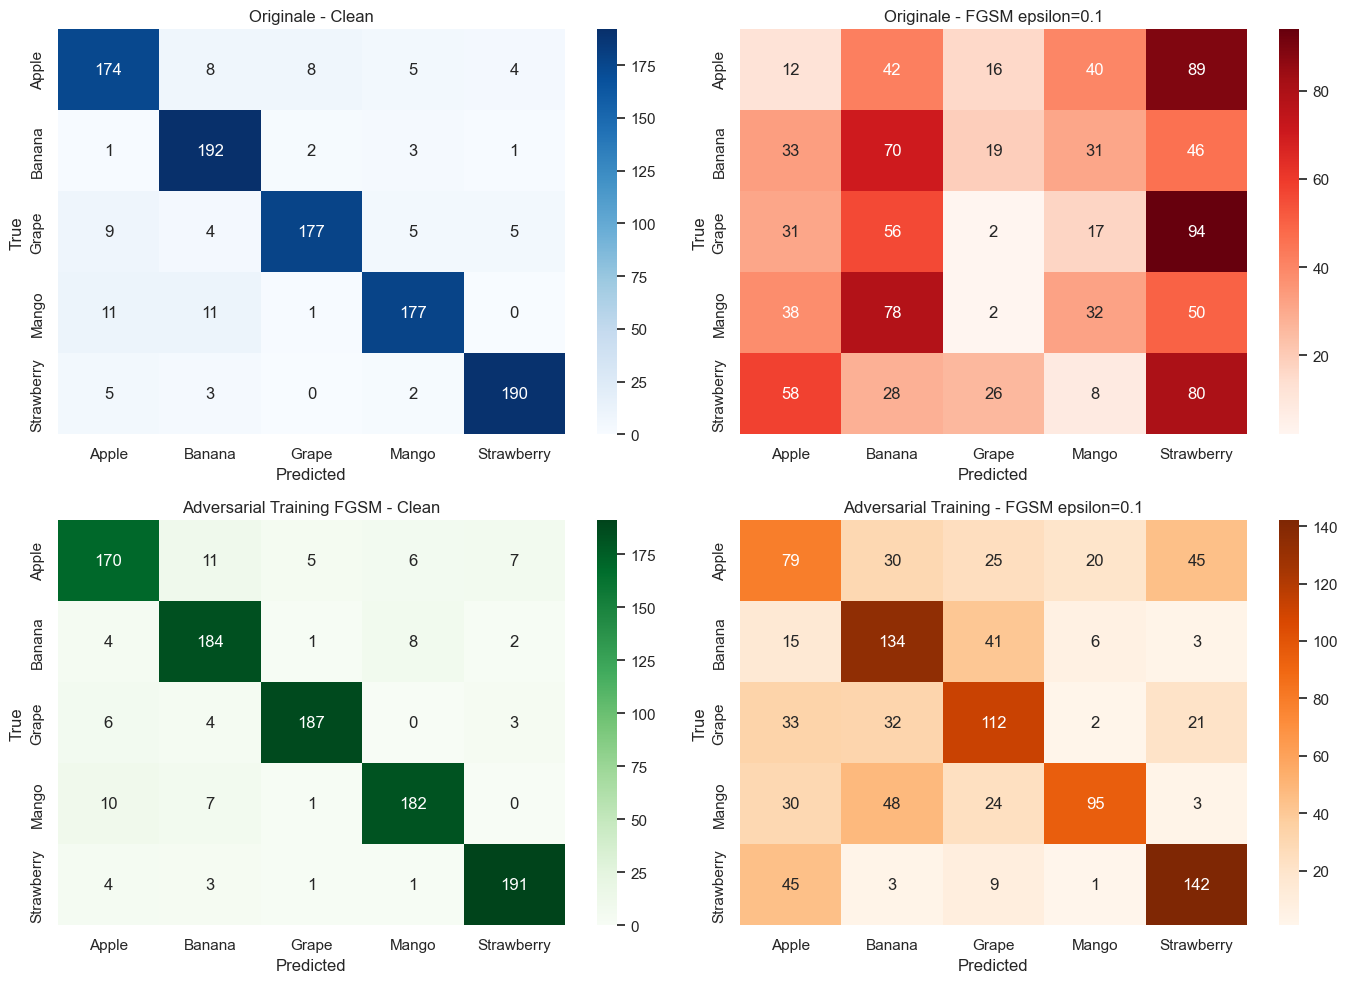

In [14]:
epsilon_test = 0.1

fgsm_model.load_state_dict(torch.load(model_save_path))

model.eval()
fgsm_model.eval()

correct_orig_clean = 0
correct_orig_adv = 0
attack_success_orig = 0

correct_fgsm_clean = 0
correct_fgsm_adv = 0
attack_success_fgsm = 0

total = 0

all_labels = []
preds_orig_clean_all = []
preds_orig_adv_all = []
preds_fgsm_clean_all = []
preds_fgsm_adv_all = []

for images, labels in tqdm(test_loader, desc=f"Confronto FGSM epsilon={epsilon_test}"):
    images = images.to(device)
    labels = labels.to(device)

    # modello originale su immagini pulite
    with torch.no_grad():
        outputs_orig_clean = model(NORMALIZE(images))
        preds_orig_clean = torch.argmax(outputs_orig_clean, dim=1)

    # modello originale su immagini adversarial
    adv_images_orig, perturbation = fgsm_attack(
        model,
        images.clone().requires_grad_(True),
        labels,
        epsilon_test,
        loss_fn
    )

    with torch.no_grad():
        outputs_orig_adv = model(NORMALIZE(adv_images_orig))
        preds_orig_adv = torch.argmax(outputs_orig_adv, dim=1)

    # modello adversarial trained su immagini pulite
    with torch.no_grad():
        outputs_fgsm_clean = fgsm_model(NORMALIZE(images))
        preds_fgsm_clean = torch.argmax(outputs_fgsm_clean, dim=1)

    # modello adversarial trained su immagini adversarial
    adv_images_fgsm, _ = fgsm_attack(
        fgsm_model,
        images.clone().requires_grad_(True),
        labels,
        epsilon_test,
        loss_fn
    )

    with torch.no_grad():
        outputs_fgsm_adv = fgsm_model(NORMALIZE(adv_images_fgsm))
        preds_fgsm_adv = torch.argmax(outputs_fgsm_adv, dim=1)

    correct_orig_clean += (preds_orig_clean == labels).sum().item()
    correct_orig_adv += (preds_orig_adv == labels).sum().item()
    attack_success_orig += ((preds_orig_clean == labels) & (preds_orig_adv != labels)).sum().item()

    correct_fgsm_clean += (preds_fgsm_clean == labels).sum().item()
    correct_fgsm_adv += (preds_fgsm_adv == labels).sum().item()
    attack_success_fgsm += ((preds_fgsm_clean == labels) & (preds_fgsm_adv != labels)).sum().item()

    total += labels.size(0)

    # per tutti i batch
    all_labels.extend(labels.cpu().numpy())
    preds_orig_clean_all.extend(preds_orig_clean.cpu().numpy())
    preds_orig_adv_all.extend(preds_orig_adv.cpu().numpy())
    preds_fgsm_clean_all.extend(preds_fgsm_clean.cpu().numpy())
    preds_fgsm_adv_all.extend(preds_fgsm_adv.cpu().numpy())

# metriche
acc_orig_clean = correct_orig_clean / total
acc_orig_adv = correct_orig_adv / total
drop_orig = acc_orig_clean - acc_orig_adv
asr_orig = attack_success_orig / correct_orig_clean

acc_fgsm_clean = correct_fgsm_clean / total
acc_fgsm_adv = correct_fgsm_adv / total
drop_fgsm = acc_fgsm_clean - acc_fgsm_adv
asr_fgsm = attack_success_fgsm / correct_fgsm_clean

comparison_df = pd.DataFrame({
    'model': ['Originale', 'Adversarial Training FGSM'],
    'epsilon_attack': [epsilon_test, epsilon_test],
    'accuracy_clean': [acc_orig_clean, acc_fgsm_clean],
    'accuracy_adversarial': [acc_orig_adv, acc_fgsm_adv],
    'accuracy_drop': [drop_orig, drop_fgsm],
    'asr': [asr_orig, asr_fgsm],
})

print(comparison_df.to_string(index=False))

comparison_df.to_csv(results_path / "FGSM_original_vs_adv.csv", index=False)

# plot heatmap
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cm_orig_clean = confusion_matrix(all_labels, preds_orig_clean_all)
cm_orig_adv = confusion_matrix(all_labels, preds_orig_adv_all)
cm_fgsm_clean = confusion_matrix(all_labels, preds_fgsm_clean_all)
cm_fgsm_adv = confusion_matrix(all_labels, preds_fgsm_adv_all)

sns.heatmap(cm_orig_clean, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 0])
axes[0, 0].set_title('Originale - Clean')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('True')

sns.heatmap(cm_orig_adv, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 1])
axes[0, 1].set_title(f'Originale - FGSM epsilon={epsilon_test}')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('True')

sns.heatmap(cm_fgsm_clean, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1, 0])
axes[1, 0].set_title('Adversarial Training FGSM - Clean')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')

sns.heatmap(cm_fgsm_adv, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1, 1])
axes[1, 1].set_title(f'Adversarial Training - FGSM epsilon={epsilon_test}')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('True')

plt.tight_layout()
plt.savefig(results_path / "FGSM_original_vs_adv.png", dpi=120, bbox_inches='tight')
plt.show()